# US Hospital Financial Performance Analysis

**In short:** every US hospital that treats Medicare patients files a yearly financial report with the federal
government. I used 13 years of these reports (2011 to 2023, about 4,300 hospitals a year) to see how much money
hospitals make or lose, which ones are struggling, and what is driving costs up.

Study group: general acute care hospitals and critical access hospitals (small rural hospitals with 25 beds or
fewer) in the 50 states and DC. Main measure: **total margin**, the share of each dollar of revenue left over as
profit (a 5% margin means 5 cents of profit on every dollar). All numbers come from the PostgreSQL analytics views
(`SQL/04_analytics_views.sql`); the same numbers with their SQL are in `SQL/query_results.md`.

In [1]:
import warnings
from importlib import import_module
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg
from matplotlib.colors import LinearSegmentedColormap

import viz_style as vs

warnings.filterwarnings("ignore")
vs.apply()
pd.set_option("display.float_format", "{:,.1f}".format)
conn = psycopg.connect(import_module("02_load_postgres").CONNINFO)

def q(sql):
    cur = conn.execute(sql)
    df = pd.DataFrame(cur.fetchall(), columns=[c.name for c in cur.description])
    for c in df.columns:                     # Decimal -> float
        if df[c].dtype == object and len(df) and not isinstance(df[c].iloc[0], str):
            df[c] = pd.to_numeric(df[c], errors="ignore")
    return df

## 1. Can this data be trusted?

MedPAC (the commission that advises Congress on Medicare) publishes the all-payer total margin of general acute
care hospitals each year from the same cost reports. Using MedPAC's rules (report dated by the federal fiscal year
that contains its midpoint, Maryland left out), my numbers match 2019 exactly and stay within about one point after
that. The small gap in 2022-2023 most likely comes from MedPAC's own outlier rules, which are not published in detail.

In [2]:
recon = q("""
SELECT midpoint_ffy AS year, count(*) AS hospitals,
       round(100 * sum(f.net_income) / sum(f.total_revenue), 1) AS this_project_pct
FROM core.fact_hospital_year f JOIN core.dim_hospital h USING (ccn)
WHERE h.hospital_type = 'General acute care' AND h.state_abbrev <> 'MD' AND NOT f.margin_outlier
  AND midpoint_ffy BETWEEN 2019 AND 2023
GROUP BY 1 ORDER BY 1""")
recon["medpac_pct"] = [7.8, 6.6, 10.6, 2.3, 6.4]
recon["difference"] = recon.this_project_pct - recon.medpac_pct
recon

,year,hospitals,this_project_pct,medpac_pct,difference
0,2019,3004,7.8,7.8,0.0
1,2020,2999,6.7,6.6,0.1
2,2021,3016,10.9,10.6,0.3
3,2022,3003,3.0,2.3,0.7
4,2023,2981,7.5,6.4,1.1


## 2. 2022 was the worst year on record: 4 in 10 hospitals lost money

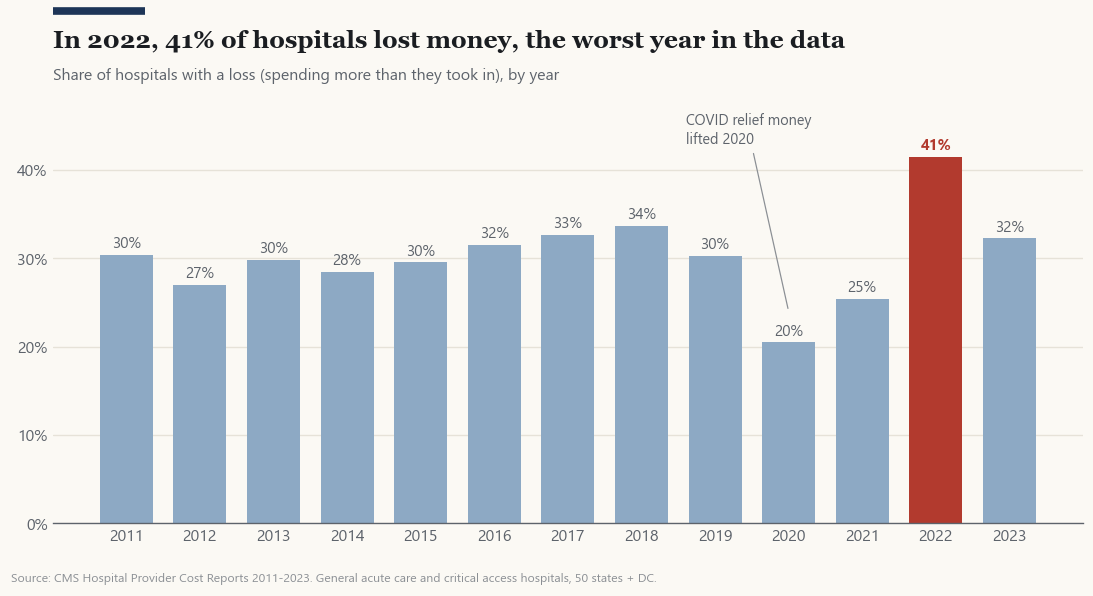

In [3]:
nat = q("SELECT * FROM analytics.v_national_trend ORDER BY fiscal_year")
nat["losing"] = 100 * nat.share_losing_money
fig, ax = plt.subplots(figsize=(10, 5))
colors = [vs.BRICK if y == 2022 else vs.NAVY_L for y in nat.fiscal_year]
bars = ax.bar(nat.fiscal_year, nat.losing, color=colors, width=0.72)
for b, v, y in zip(bars, nat.losing, nat.fiscal_year):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.8, f"{v:.0f}%", ha="center", fontsize=10,
            color=vs.BRICK if y == 2022 else vs.INK_2, fontweight="bold" if y == 2022 else "normal")
ax.annotate("COVID relief money\nlifted 2020", (2020, nat.losing[nat.fiscal_year == 2020].iloc[0] + 3.5), xytext=(2018.6, 43),
            fontsize=9.5, color=vs.INK_2, arrowprops=dict(arrowstyle="-", color=vs.GREY, lw=0.8))
ax.set_xticks(nat.fiscal_year); ax.set_ylim(0, 48); vs.pct(ax)
vs.title(ax, "In 2022, 41% of hospitals lost money, the worst year in the data",
         "Share of hospitals with a loss (spending more than they took in), by year")
vs.source(fig); vs.save(fig, "losing_money_trend"); fig

In [4]:
nat[["fiscal_year", "hospitals", "total_margin_aggregate", "total_margin_median", "losing"]].assign(
    total_margin_aggregate=lambda d: 100 * d.total_margin_aggregate,
    total_margin_median=lambda d: 100 * d.total_margin_median).rename(columns={
    "total_margin_aggregate": "all hospitals combined margin %", "total_margin_median": "typical (median) margin %",
    "losing": "% losing money"})

,fiscal_year,hospitals,all hospitals combined margin %,typical (median) margin %,% losing money
0,2011,4571,5.3,3.2,30.4
1,2012,4577,6.6,4.1,27.0
2,2013,4558,7.4,3.9,29.9
3,2014,4506,8.0,4.3,28.5
4,2015,4494,6.0,3.9,29.6
5,2016,4480,6.8,3.8,31.5
6,2017,4418,7.2,3.5,32.6
7,2018,4391,6.8,3.5,33.7
8,2019,4344,6.8,4.2,30.3
9,2020,4349,9.6,7.8,20.5


## 3. Financial stress: one hospital in four lost money two years in a row in 2023

A single bad year can be bad luck. Losing money **two years in a row** is a warning sign. (I first tried "losing
money with less than 30 days of cash", but hospitals that belong to a health system often hold almost no cash of
their own because the parent company keeps it: the typical for-profit hospital reports 0 days. So cash cannot be
used to judge a single hospital.)

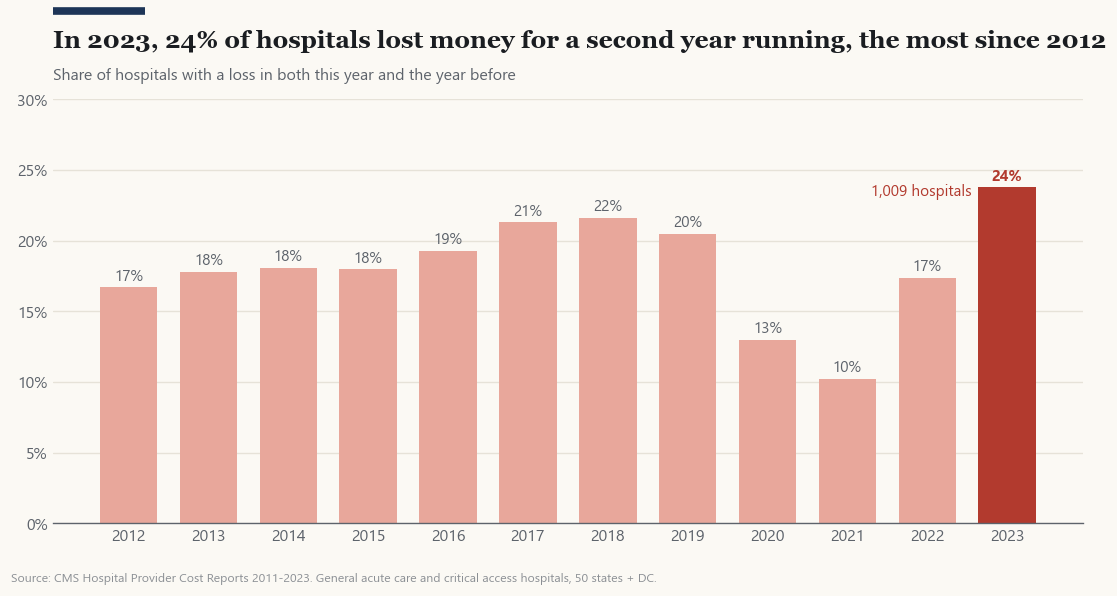

In [5]:
stress = q("""SELECT fiscal_year, sum(stressed)::float / sum(hospitals) * 100 AS pct, sum(stressed) AS n
               FROM analytics.v_financial_stress GROUP BY 1 ORDER BY 1""")
fig, ax = plt.subplots(figsize=(10, 5))
colors = [vs.BRICK if y == 2023 else vs.BRICK_L for y in stress.fiscal_year]
bars = ax.bar(stress.fiscal_year, stress.pct, color=colors, width=0.72)
for b, v, n, y in zip(bars, stress.pct, stress.n, stress.fiscal_year):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.0f}%", ha="center", fontsize=10,
            color=vs.BRICK if y == 2023 else vs.INK_2, fontweight="bold" if y == 2023 else "normal")
last = stress.iloc[-1]
ax.text(2022.55, last.pct - 0.6, f"{int(last.n):,} hospitals", ha="right", color=vs.BRICK, fontsize=10)
ax.set_xticks(stress.fiscal_year); ax.set_ylim(0, 30); vs.pct(ax)
vs.title(ax, "In 2023, 24% of hospitals lost money for a second year running, the most since 2012",
         "Share of hospitals with a loss in both this year and the year before")
vs.source(fig); vs.save(fig, "stress_trend"); fig

## 4. Who is struggling: rural and government hospitals

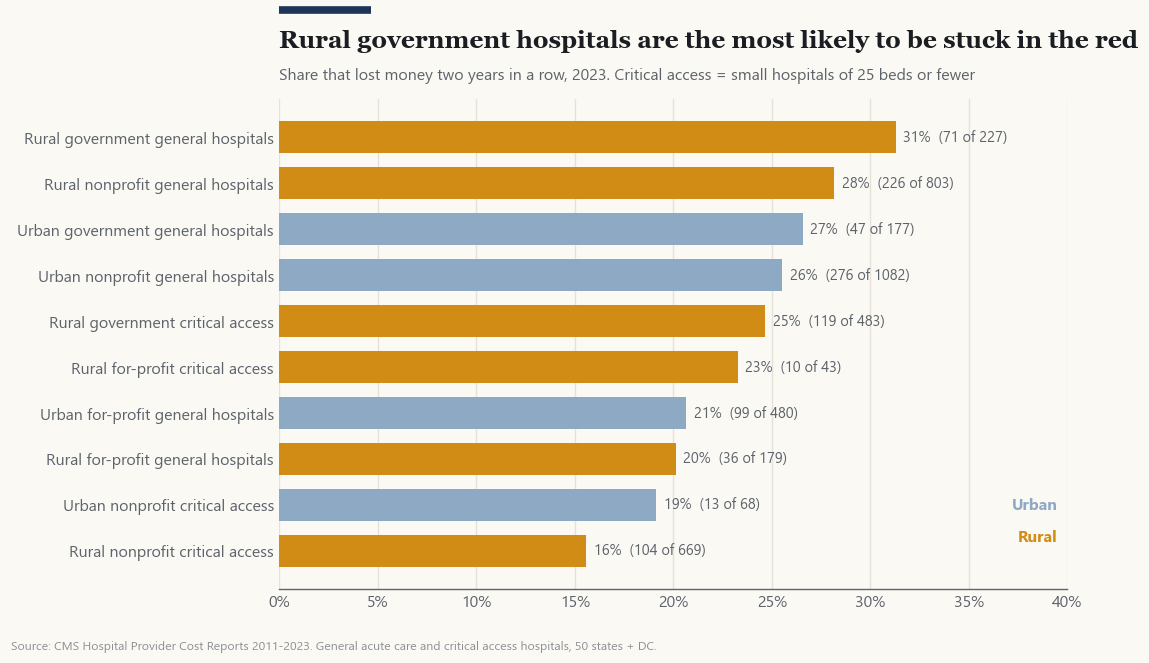

In [6]:
grp = q("""SELECT hospital_type, rural_urban, ownership, hospitals, stressed, 100 * stressed_share AS pct
             FROM analytics.v_financial_stress WHERE fiscal_year = 2023 AND hospitals >= 30
             ORDER BY stressed_share""")
short = {"General acute care": "general hospitals", "Critical access": "critical access"}
grp["label"] = grp.rural_urban + " " + grp.ownership.str.lower() + " " + grp.hospital_type.map(short)
fig, ax = plt.subplots(figsize=(10, 5.6))
colors = [vs.OCHRE if r == "Rural" else vs.NAVY_L for r in grp.rural_urban]
ax.barh(grp.label, grp.pct, color=colors, height=0.7)
for i, (v, n, h) in enumerate(zip(grp.pct, grp.stressed, grp.hospitals)):
    ax.text(v + 0.4, i, f"{v:.0f}%  ({n} of {h})", va="center", fontsize=9.5, color=vs.INK_2)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True); ax.set_xlim(0, 40); vs.pct(ax, "x")
ax.text(39.5, 0.2, "Rural", color=vs.OCHRE, fontweight="bold", ha="right")
ax.text(39.5, 0.9, "Urban", color=vs.NAVY_L, fontweight="bold", ha="right")
vs.title(ax, "Rural government hospitals are the most likely to be stuck in the red",
         "Share that lost money two years in a row, 2023. Critical access = small hospitals of 25 beds or fewer")
vs.source(fig); vs.save(fig, "stress_by_group"); fig

In [7]:
own = q("""SELECT ownership, fiscal_year, hospitals, 100 * total_margin_median AS median_margin_pct,
                    100 * share_losing_money AS pct_losing_money
             FROM analytics.v_type_ownership WHERE hospital_type = 'General acute care' AND fiscal_year IN (2019, 2023)
             ORDER BY 1, 2""")
own

,ownership,fiscal_year,hospitals,median_margin_pct,pct_losing_money
0,For-profit,2019,735,7.9,26.8
1,For-profit,2023,685,8.5,28.5
2,Government,2019,434,2.3,36.9
3,Government,2023,412,1.8,40.3
4,Nonprofit,2019,1859,4.7,28.9
5,Nonprofit,2023,1917,3.9,32.6


For-profit hospitals kept the highest typical margin (8.5% in 2023) while government hospitals had the lowest
(1.8%) and the highest share losing money (40%). Critical access hospitals are paid by Medicare on their costs,
which protects them: they are less likely to be stuck in losses than general hospitals of the same kind.

## 5. Where: the share of hospitals losing money by state (2023)

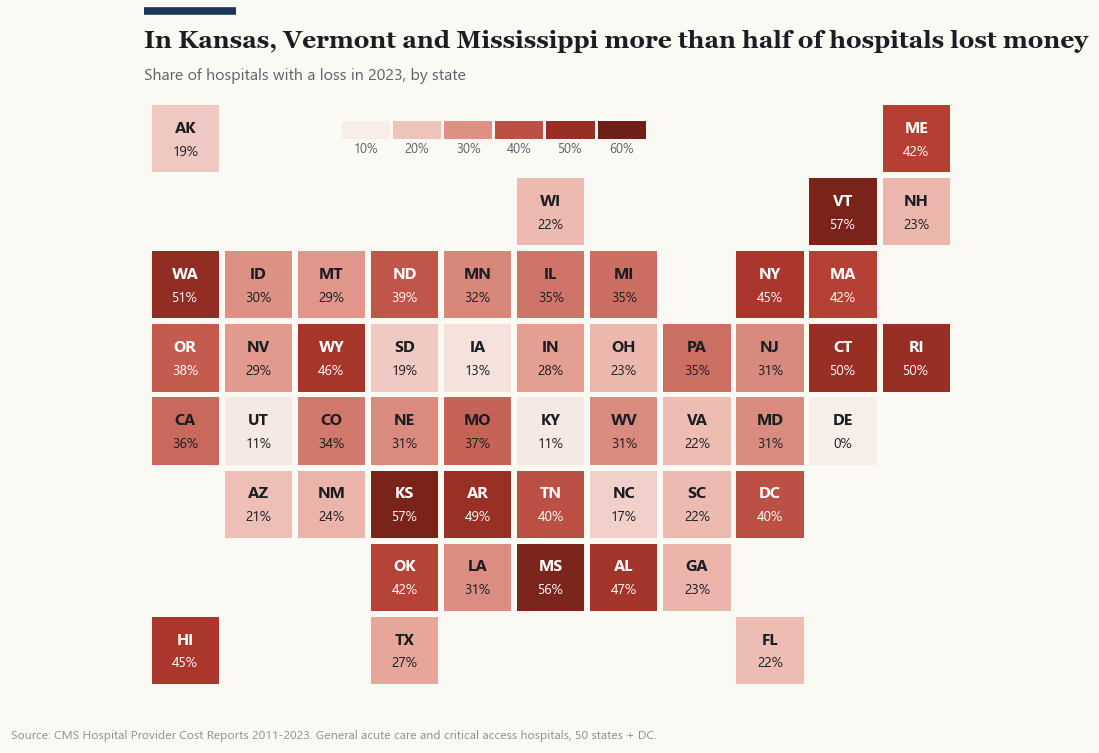

In [8]:
st = q("SELECT state_abbrev, hospitals, 100 * share_losing_money AS pct, medicaid_status FROM analytics.v_state_scorecard")
cmap = LinearSegmentedColormap.from_list("brick", ["#f7ede9", vs.BRICK_L, vs.BRICK, "#6e1f17"])
lo, hi = 10, 60
fig, ax = plt.subplots(figsize=(10, 6.4))
for _, r in st.iterrows():
    c, row = vs.STATE_GRID[r.state_abbrev]
    val = (min(max(r.pct, lo), hi) - lo) / (hi - lo)
    ax.add_patch(plt.Rectangle((c, -row), 0.92, 0.92, color=cmap(val), lw=0))
    txt = "white" if val > 0.55 else vs.INK
    ax.text(c + 0.46, -row + 0.6, r.state_abbrev, ha="center", va="center", fontsize=10.5, fontweight="bold", color=txt)
    ax.text(c + 0.46, -row + 0.28, f"{r.pct:.0f}%", ha="center", va="center", fontsize=9, color=txt)
ax.set_xlim(-0.1, 11); ax.set_ylim(-7.2, 1.0); ax.set_aspect("equal"); ax.axis("off")
for i, v in enumerate([10, 20, 30, 40, 50, 60]):
    ax.add_patch(plt.Rectangle((2.6 + i * 0.7, 0.45), 0.66, 0.25, color=cmap((v - lo) / (hi - lo)), lw=0))
    ax.text(2.93 + i * 0.7, 0.4, f"{v}%", ha="center", va="top", fontsize=8.5, color=vs.INK_2)
vs.title(ax, "In Kansas, Vermont and Mississippi more than half of hospitals lost money",
         "Share of hospitals with a loss in 2023, by state")
vs.source(fig); vs.save(fig, "state_map"); fig

In [9]:
st.sort_values('pct', ascending=False).head(10)

,state_abbrev,hospitals,pct,medicaid_status
4,KS,126,57.1,Not expanded
28,VT,14,57.1,Expanded
15,MS,87,56.3,Not expanded
25,WA,84,51.2,Expanded
0,CT,28,50.0,Expanded
3,RI,10,50.0,Expanded
40,AR,73,49.3,Expanded
45,AL,83,47.0,Not expanded
29,WY,26,46.2,Not expanded
34,NY,153,45.1,Expanded


## 6. Why: the cost of a hospital stay nearly doubled, and agency staff costs spiked

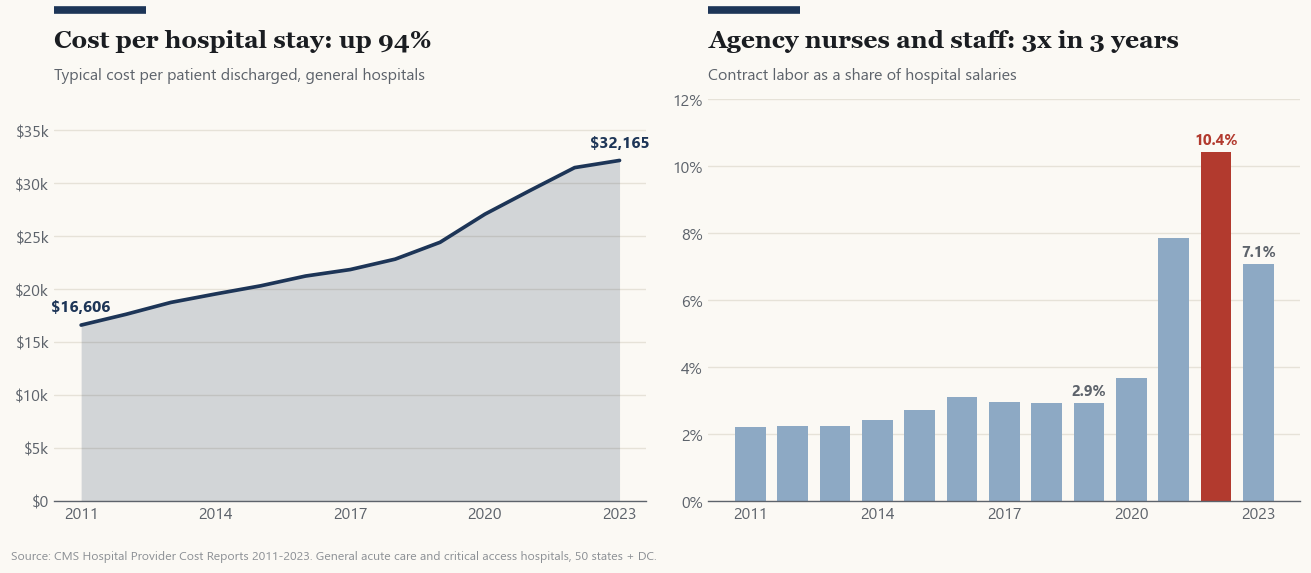

In [10]:
cost = q("SELECT * FROM analytics.v_cost_trend ORDER BY fiscal_year")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.8))
a1.fill_between(cost.fiscal_year, cost.cost_per_discharge_median, color=vs.NAVY, alpha=0.18, lw=0)
a1.plot(cost.fiscal_year, cost.cost_per_discharge_median, color=vs.NAVY)
for y in (2011, 2023):
    v = cost.cost_per_discharge_median[cost.fiscal_year == y].iloc[0]
    a1.text(y, v + 1300, f"${v:,.0f}", ha="center", fontsize=10.5, fontweight="bold", color=vs.NAVY)
a1.set_ylim(0, 38000); vs.dollars(a1); a1.set_xticks([2011, 2014, 2017, 2020, 2023])
vs.title(a1, "Cost per hospital stay: up 94%", "Typical cost per patient discharged, general hospitals")
colors = [vs.BRICK if y == 2022 else vs.NAVY_L for y in cost.fiscal_year]
cl = 100 * cost.contract_labor_pct
a2.bar(cost.fiscal_year, cl, color=colors, width=0.72)
for y, v in zip(cost.fiscal_year, cl):
    if y in (2019, 2022, 2023):
        a2.text(y, v + 0.25, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold",
                color=vs.BRICK if y == 2022 else vs.INK_2)
a2.set_ylim(0, 12); vs.pct(a2); a2.set_xticks([2011, 2014, 2017, 2020, 2023])
vs.title(a2, "Agency nurses and staff: 3x in 3 years", "Contract labor as a share of hospital salaries")
vs.source(fig); vs.save(fig, "cost_pressure"); fig

The typical cost of a hospital stay went from about \$16,600 in 2011 to \$32,200 in 2023. During COVID, hospitals
filled staff gaps with travel nurses and other agency staff: that spending rose from 2.9% of salaries in 2019 to 10.4%
in 2022, the year margins fell the most. It came down in 2023 (7.1%) and so did the share of hospitals losing money.

## 7. Medicaid expansion and unpaid care

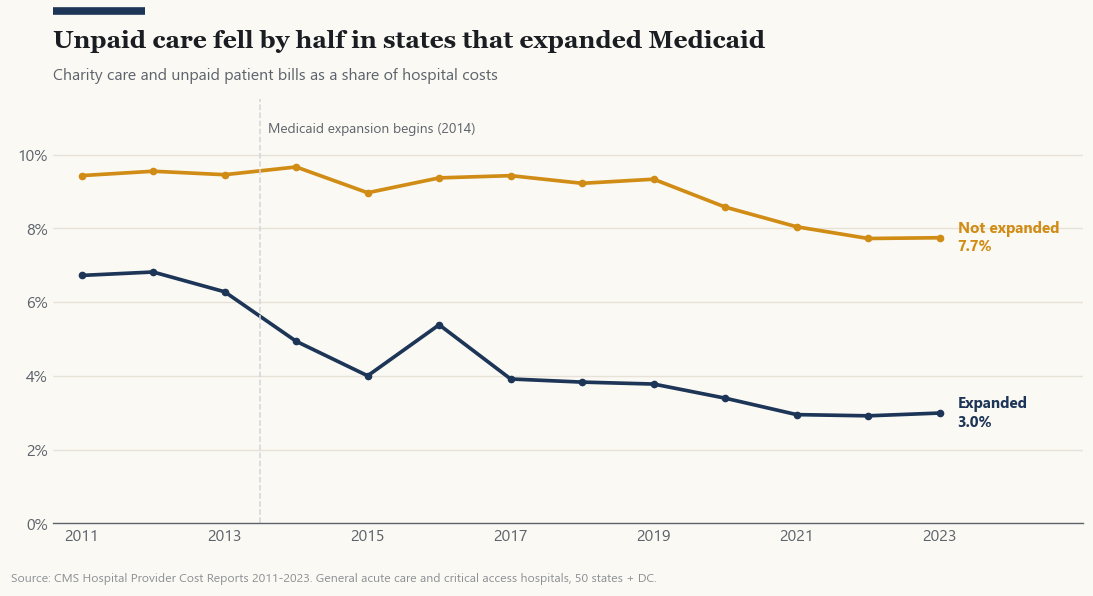

In [11]:
unc = q("SELECT fiscal_year, medicaid_status, 100 * uncompensated_care_pct AS pct FROM analytics.v_medicaid_uncompensated")
w = unc.pivot(index="fiscal_year", columns="medicaid_status", values="pct")
fig, ax = plt.subplots(figsize=(10, 5))
for col, color in (("Not expanded", vs.OCHRE), ("Expanded", vs.NAVY)):
    ax.plot(w.index, w[col], color=color, marker="o", ms=4)
    ax.text(2023.25, w[col].iloc[-1], f"{col}\n{w[col].iloc[-1]:.1f}%", color=color, va="center",
            fontsize=10, fontweight="bold")
ax.axvline(2013.5, color=vs.GREY_L, lw=1, ls="--")
ax.text(2013.6, 10.6, "Medicaid expansion begins (2014)", color=vs.INK_2, fontsize=9)
ax.set_xlim(2010.6, 2025); ax.set_xticks(range(2011, 2024, 2)); ax.set_ylim(0, 11.5); vs.pct(ax)
vs.title(ax, "Unpaid care fell by half in states that expanded Medicaid",
         "Charity care and unpaid patient bills as a share of hospital costs")
vs.source(fig); vs.save(fig, "uncompensated_care"); fig

Before 2014 the two groups were already different (6.7% vs 9.4%), but the gap widened after expansion: unpaid care
fell to 3.0% of costs in expansion states and stayed near 8% in the others. This is a before/after comparison, not a
causal estimate; my [Medicaid expansion project](https://github.com/Isaac-Agyapong/Medicaid_Expansion_Impact_Model)
measures the coverage effect with a proper causal method.

## 8. Prices: hospitals bill Medicare almost 5 times what they are paid

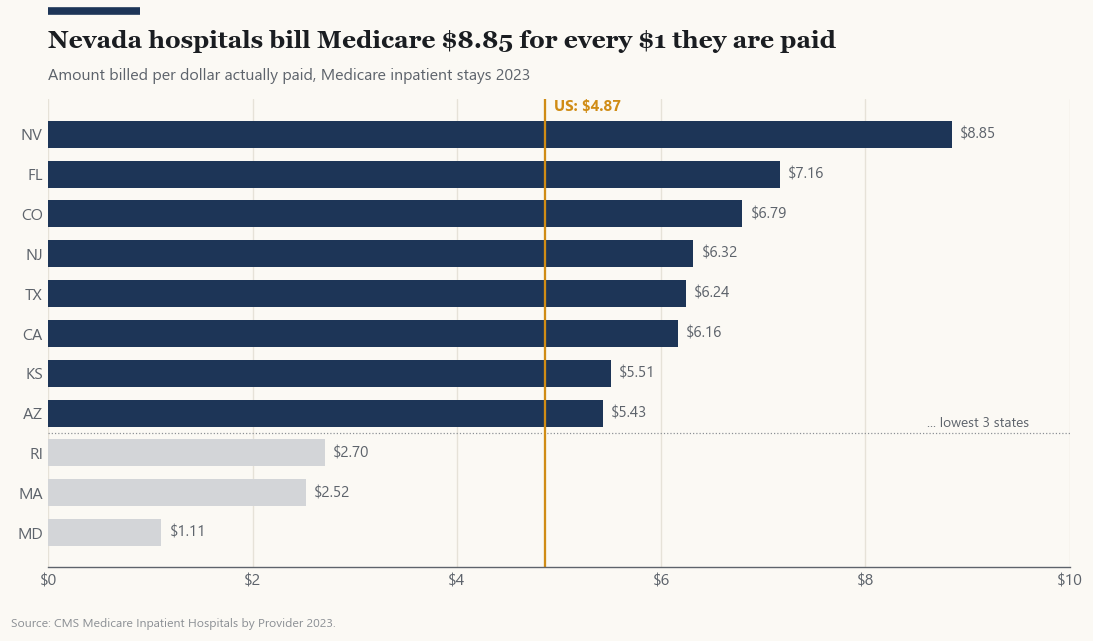

In [12]:
bill = q("""SELECT state_abbrev, billed_per_dollar_paid AS ratio FROM analytics.v_charges_vs_payments
              WHERE data_year = 2023 ORDER BY ratio DESC""")
us = q("""SELECT sum(submitted_charges) / sum(total_payment) AS r FROM core.fact_inpatient_year WHERE data_year = 2023""").r[0]
top = pd.concat([bill.head(8), bill.tail(3)]).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5.4))
colors = [vs.NAVY if i >= 3 else vs.GREY_L for i in range(len(top))]
ax.barh(top.state_abbrev, top.ratio, color=colors, height=0.68)
for i, v in enumerate(top.ratio):
    ax.text(v + 0.08, i, f"${v:.2f}", va="center", fontsize=10, color=vs.INK_2)
ax.axhline(2.5, color=vs.GREY, lw=0.8, ls=":")
ax.text(9.6, 2.65, "... lowest 3 states", ha="right", fontsize=9, color=vs.INK_2)
ax.axvline(us, color=vs.OCHRE, lw=1.5)
ax.text(us + 0.08, len(top) - 0.4, f"US: ${us:.2f}", color=vs.OCHRE, fontweight="bold", fontsize=10)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True); ax.set_xlim(0, 10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:.0f}"))
vs.title(ax, "Nevada hospitals bill Medicare \$8.85 for every \$1 they are paid",
         "Amount billed per dollar actually paid, Medicare inpatient stays 2023")
vs.source(fig, "Source: CMS Medicare Inpatient Hospitals by Provider 2023.")
vs.save(fig, "billed_vs_paid"); fig

A hospital's list price (its "charge") is not what it gets paid: Medicare sets its own rates. The US average was
\$4.87 billed for every \$1 paid in 2023, up from \$3.85 in 2013. Maryland sets hospital prices by law, which is
why it sits at the bottom.

## 9. Some hospitals lose money year after year

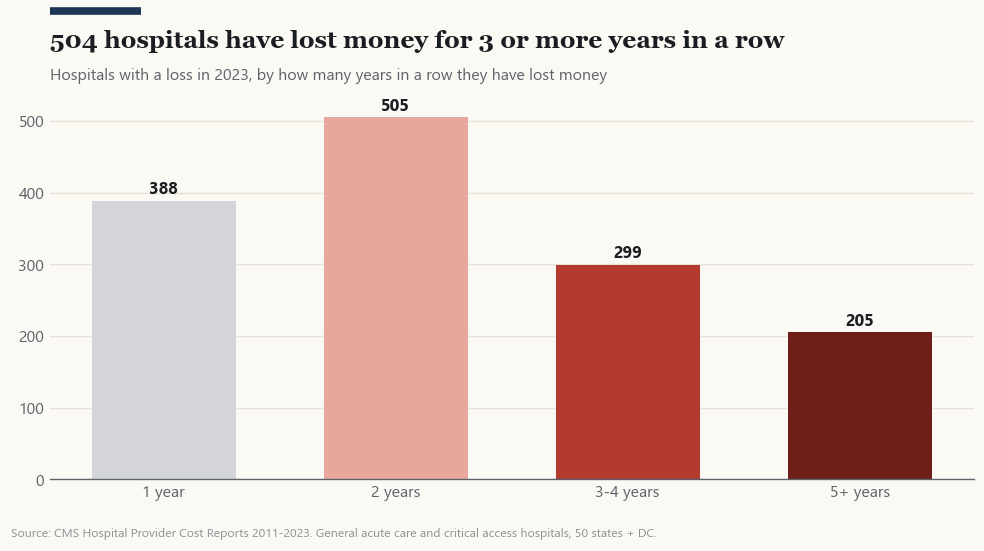

In [13]:
streak = q("SELECT years_in_a_row, count(*) AS hospitals FROM analytics.v_loss_streaks GROUP BY 1 ORDER BY 1")
streak["band"] = pd.cut(streak.years_in_a_row, [0, 1, 2, 4, 13], labels=["1 year", "2 years", "3-4 years", "5+ years"])
b = streak.groupby("band", observed=False).hospitals.sum()
fig, ax = plt.subplots(figsize=(9, 4.6))
colors = [vs.GREY_L, vs.BRICK_L, vs.BRICK, "#6e1f17"]
bars = ax.bar(b.index.astype(str), b.values, color=colors, width=0.62)
for bar, v in zip(bars, b.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 10, f"{v:,}", ha="center", fontsize=11, fontweight="bold")
vs.title(ax, f"{b.iloc[2:].sum():,} hospitals have lost money for 3 or more years in a row",
         "Hospitals with a loss in 2023, by how many years in a row they have lost money")
vs.source(fig); vs.save(fig, "loss_streaks"); fig

## 10. Hospitals with the most Medicaid patients lose money more often

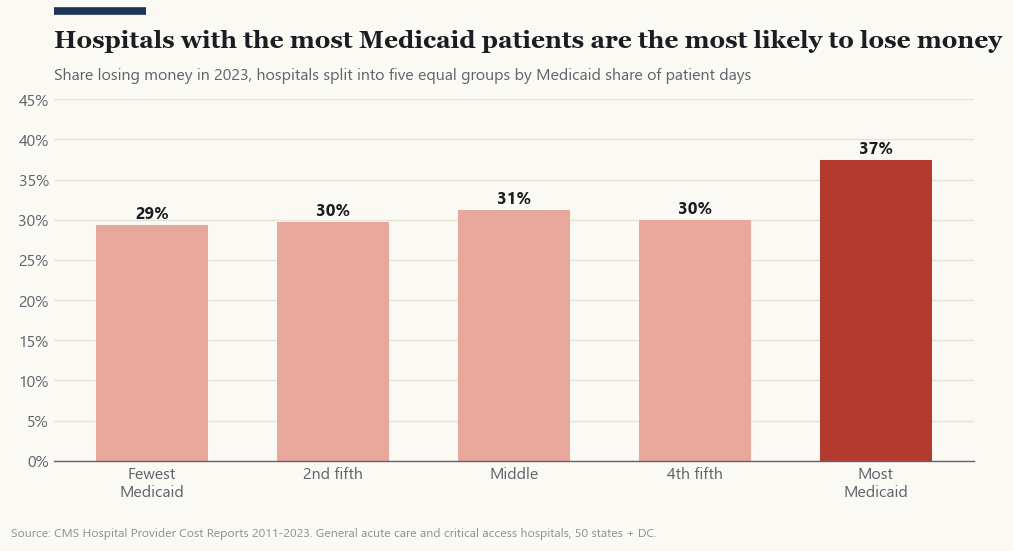

In [14]:
mc = q("""
SELECT band, count(*) AS hospitals, 100 * percentile_cont(0.5) WITHIN GROUP (ORDER BY total_margin) AS median_margin,
       100 * avg((net_income < 0)::int) AS pct_losing
FROM (SELECT *, ntile(5) OVER (ORDER BY medicaid_day_share) AS band FROM analytics.v_hospital_year
      WHERE fiscal_year = 2023 AND medicaid_day_share BETWEEN 0 AND 1) x
GROUP BY band ORDER BY band""")
mc["label"] = ["Fewest\nMedicaid", "", "", "", "Most\nMedicaid"]
fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.bar(range(5), mc.pct_losing, color=[vs.BRICK_L] * 4 + [vs.BRICK], width=0.62)
for bar, v in zip(bars, mc.pct_losing):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.8, f"{v:.0f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(range(5), ["Fewest\nMedicaid", "2nd fifth", "Middle", "4th fifth", "Most\nMedicaid"])
ax.set_ylim(0, 45); vs.pct(ax)
vs.title(ax, "Hospitals with the most Medicaid patients are the most likely to lose money",
         "Share losing money in 2023, hospitals split into five equal groups by Medicaid share of patient days")
vs.source(fig); vs.save(fig, "medicaid_share"); fig

In [15]:
mc.drop(columns='label')

,band,hospitals,median_margin,pct_losing
0,1,780,5.6,29.4
1,2,780,4.8,29.7
2,3,780,4.8,31.2
3,4,780,4.9,30.0
4,5,780,2.4,37.4


## Summary

1. The data matches MedPAC's published margins, so the numbers can be trusted.
2. 2022 was the worst year in the data: 41% of hospitals lost money.
3. In 2023, 24% of hospitals (about 1,000) lost money for a second year running, the most since 2012.
4. Rural and government hospitals are the most likely to be stuck in losses; for-profit hospitals earn the most.
5. The cost of a hospital stay nearly doubled since 2011, and agency staffing tripled during COVID.
6. Unpaid care fell by half in states that expanded Medicaid and stayed high elsewhere.

The companion machine learning project uses these hospital-year records to forecast which hospitals will fall into
financial distress in the next two years.